In [ ]:
# first, import the Pandas library.
import pandas as pd

df = pd.read_csv('Salary by Education.csv')
df.head()


,Degree Level,Nationality,Gender,Year Quarter,Salary,Currency
0,Primary,NonSaudi,Female,2017 Q1,1590,SAR
1,Primary,NonSaudi,Male,2017 Q1,2173,SAR
2,Primary,Saudi,Female,2017 Q1,4172,SAR
3,Primary,Saudi,Male,2017 Q1,6172,SAR
4,Primary,NonSaudi,Female,2017 Q2,1597,SAR


In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Degree Level  504 non-null    str  
 1   Nationality   504 non-null    str  
 2   Gender        504 non-null    str  
 3   Year Quarter  504 non-null    str  
 4   Salary        504 non-null    int64
 5   Currency      504 non-null    str  
dtypes: int64(1), str(5)
memory usage: 23.8 KB


,Salary
count,504.000000
mean,8950.031746
std,6372.635277
min,1331.000000
25%,4194.000000
50%,7890.500000
75%,12448.750000
max,35622.000000


In [6]:
df.groupby(['Degree Level','Gender'])['Salary'].mean()

Degree Level   Gender
Bachelor       Female     8417.750000
               Male      10653.361111
Diploma        Female     6694.055556
               Male       7379.333333
Doctorate      Female    17172.750000
               Male      22498.166667
Intermediate   Female     3161.000000
               Male       5042.055556
Master Degree  Female    11605.166667
               Male      15990.583333
Primary        Female     2929.444444
               Male       4208.638889
Secondary      Female     3671.750000
               Male       5876.388889
Name: Salary, dtype: float64

In [8]:
#  I convert the table so that Gender has separate columns (instead of nested rows)
salary_pivot = df.groupby(['Degree Level', 'Gender'])['Salary'].mean().unstack()
print(salary_pivot)

# I calculate the absolute difference and the percentage
salary_pivot['Gap_SAR'] = salary_pivot['Male'] - salary_pivot['Female']
salary_pivot['Gap_Percent'] = (salary_pivot['Gap_SAR'] / salary_pivot['Female'] * 100).round(1)

print(salary_pivot)

Gender               Female          Male
Degree Level                             
Bachelor        8417.750000  10653.361111
Diploma         6694.055556   7379.333333
Doctorate      17172.750000  22498.166667
Intermediate    3161.000000   5042.055556
Master Degree  11605.166667  15990.583333
Primary         2929.444444   4208.638889
Secondary       3671.750000   5876.388889
Gender               Female          Male      Gap_SAR  Gap_Percent
Degree Level                                                       
Bachelor        8417.750000  10653.361111  2235.611111         26.6
Diploma         6694.055556   7379.333333   685.277778         10.2
Doctorate      17172.750000  22498.166667  5325.416667         31.0
Intermediate    3161.000000   5042.055556  1881.055556         59.5
Master Degree  11605.166667  15990.583333  4385.416667         37.8
Primary         2929.444444   4208.638889  1279.194444         43.7
Secondary       3671.750000   5876.388889  2204.638889         60.0


In [10]:
print("Highest relative gap:")
print(salary_pivot['Gap_Percent'].idxmax(), "-", salary_pivot['Gap_Percent'].max(), "%")

print("Highest average salary (male):")
print(salary_pivot['Male'].idxmax(), "-", salary_pivot['Male'].max())

Highest relative gap:
Secondary - 60.0 %
Highest average salary (male):
Doctorate - 22498.166666666668


"Based on the analysis above, I observe that there is a gap between male and female salaries at every education level. Interestingly, this gap does not simply increase with education — the relative (percentage) gap is actually higher at the Secondary level (60%) than at the Doctorate level (31%), even though Doctorate holders earn more in absolute terms."

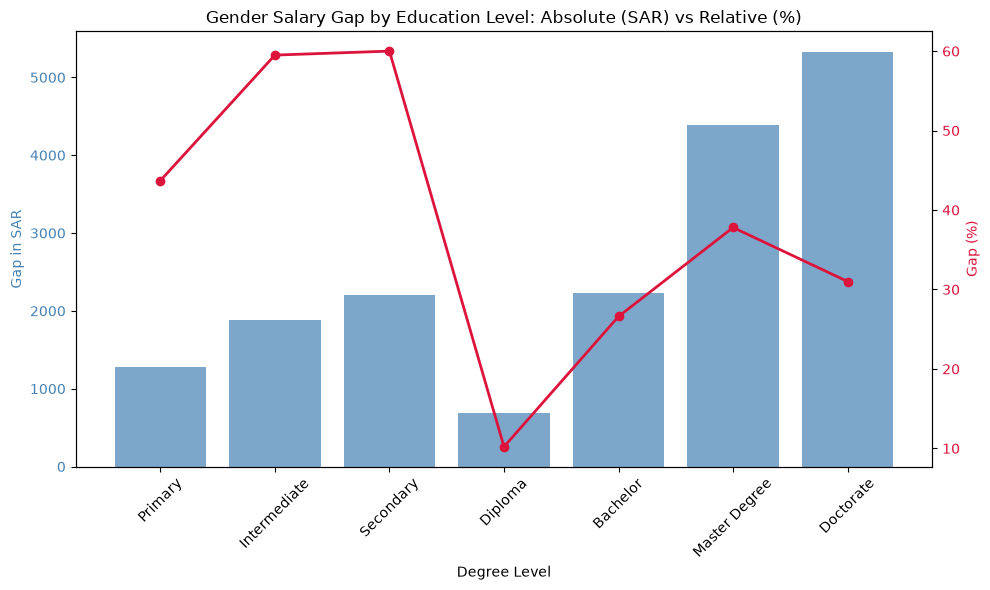

In [12]:
import matplotlib.pyplot as plt

# Sort by education level in a logical order (not alphabetical)
order = ['Primary', 'Intermediate', 'Secondary', 'Diploma', 'Bachelor', 'Master Degree', 'Doctorate']
salary_pivot = salary_pivot.reindex(order)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for the absolute gap (SAR) - left axis
ax1.bar(salary_pivot.index, salary_pivot['Gap_SAR'], color='steelblue', alpha=0.7, label='Gap in SAR')
ax1.set_xlabel('Degree Level')
ax1.set_ylabel('Gap in SAR', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
plt.xticks(rotation=45)

# Line chart for the percentage gap - right axis
ax2 = ax1.twinx()
ax2.plot(salary_pivot.index, salary_pivot['Gap_Percent'], color='crimson', marker='o', linewidth=2, label='Gap %')
ax2.set_ylabel('Gap (%)', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')

plt.title('Gender Salary Gap by Education Level: Absolute (SAR) vs Relative (%)')
fig.tight_layout()
plt.show()

In [13]:
# I extract the year from the "Year Quarter" column (e.g. "2017 Q1" -> 2017)
df['Year'] = df['Year Quarter'].str.split(' ').str[0].astype(int)
df.head()

,Degree Level,Nationality,Gender,Year Quarter,Salary,Currency,Year
0,Primary,NonSaudi,Female,2017 Q1,1590,SAR,2017
1,Primary,NonSaudi,Male,2017 Q1,2173,SAR,2017
2,Primary,Saudi,Female,2017 Q1,4172,SAR,2017
3,Primary,Saudi,Male,2017 Q1,6172,SAR,2017
4,Primary,NonSaudi,Female,2017 Q2,1597,SAR,2017


In [14]:
yearly_gender = df.groupby(['Year', 'Gender'])['Salary'].mean().unstack()
yearly_gender['Gap_Percent'] = ((yearly_gender['Male'] - yearly_gender['Female']) / yearly_gender['Female'] * 100).round(1)
print(yearly_gender)

Gender       Female          Male  Gap_Percent
Year                                          
2017    7398.410714   9837.892857         33.0
2018    7620.446429   9982.160714         31.0
2019    7870.607143  10357.464286         31.6
2020    7769.410714  10139.696429         30.5
2021    7663.285714  11485.107143         49.9


In [15]:
# I check how many records exist per year to verify data completeness
print(df['Year'].value_counts().sort_index())

Year
2017    112
2018    112
2019    112
2020    112
2021     56
Name: count, dtype: int64


"While analyzing the dataset, I discovered a data completeness issue in 2021. This year only contains 2 quarters instead of 4, which results in only 56 records compared to 112 in other years. This partial data likely explains the sudden jump in the gender pay gap for 2021 and should be treated with caution."

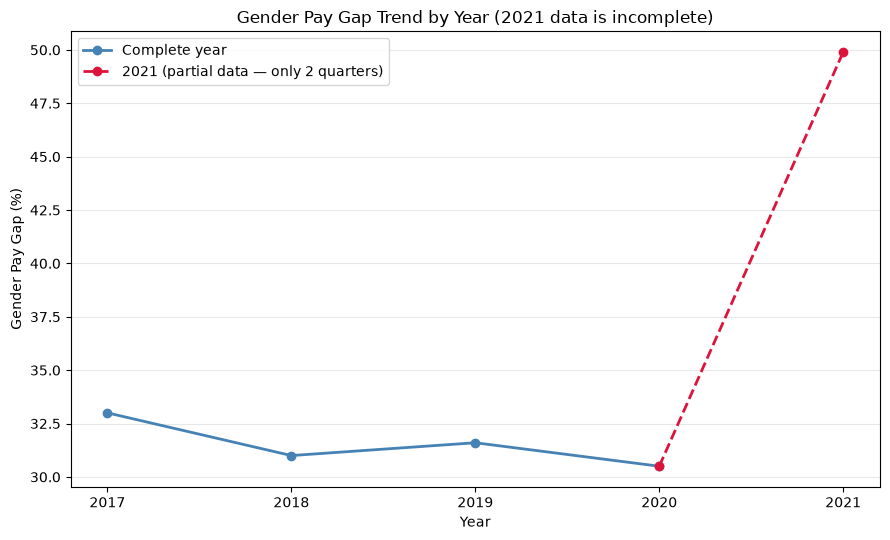

In [16]:
import matplotlib.pyplot as plt

# I plot the trend, marking 2021 differently since it has incomplete data
fig, ax = plt.subplots(figsize=(9, 5.5))

# Split the data: full years vs partial year
full_years = yearly_gender.loc[2017:2020]
partial_year = yearly_gender.loc[2020:2021]  # includes 2020 to connect the line

# Solid line for complete years
ax.plot(full_years.index, full_years['Gap_Percent'], color='steelblue', marker='o', linewidth=2, label='Complete year')

# Dashed line for the segment leading into the incomplete year
ax.plot(partial_year.index, partial_year['Gap_Percent'], color='crimson', marker='o', linewidth=2, linestyle='--', label='2021 (partial data — only 2 quarters)')

ax.set_xlabel('Year')
ax.set_ylabel('Gender Pay Gap (%)')
ax.set_title('Gender Pay Gap Trend by Year (2021 data is incomplete)')
ax.set_xticks(yearly_gender.index)
ax.legend()
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
plt.show()